In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import joblib



In [2]:
file = pd.read_csv('../datasets/feature_engineered_pima.csv')
train = file.copy()
train.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Pregnancies_Risk,...,SkinThickness_Risk,Pedigree_Risk,Metabolic_Score,High_Metabolic_Risk,Glucose_Insulin_ratio,Insulin_Glucose_ratio,BMI_Age_ratio,Age_BMI_interaction,Skin_BMI_ratio,BloodPressure_Age_ratio
0,6.0,148.0,72.0,35.0,169.0,33.6,0.627,50.0,1.0,1,...,1,1,6,1,0.875740,1.141892,0.672000,1680.0,1.041667,1.440000
1,1.0,85.0,66.0,29.0,58.6,26.6,0.351,31.0,0.0,0,...,0,0,1,0,1.450512,0.689412,0.858064,824.6,1.090226,2.129032
2,8.0,183.0,64.0,25.8,164.6,23.3,0.672,32.0,1.0,1,...,0,1,4,1,1.111786,0.899454,0.728125,745.6,1.107296,2.000000
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0,0,...,0,0,0,0,0.946809,1.056180,1.338095,590.1,0.818505,3.142857
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0,0,...,1,1,4,1,0.815476,1.226277,1.306061,1422.3,0.812065,1.212121


In [3]:
train.columns
len(train.columns)

23

In [4]:
X = train.drop(['Outcome'],axis=1)
y = train['Outcome']

# 确保特征列备份
X_cols = X.columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 此处可保留原始未缩放数据，方便解释性分析
X_train_unscaled = X_train.copy()
X_test_unscaled = X_test.copy()

print('训练集样本数：', X_train.shape[0], '测试集样本数：', X_test.shape[0])
print('各类别分布：')
print(y_train.value_counts())


d:\Anaconda3\envs\my_env\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


训练集样本数： 750 测试集样本数： 192
各类别分布：
Outcome
0.0    375
1.0    375
Name: count, dtype: int64



Training Logistic Regression...
Error with parallel processing: 'ascii' codec can't encode characters in position 18-20: ordinal not in range(128)
Falling back to single process...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

----- Logistic Regression best model -----
best params: {'clf__C': 1, 'clf__penalty': 'l2'}
accuracy: 0.7447916666666666
precision: 0.6285714285714286
recall: 0.6567164179104478
f1: 0.6423357664233577
roc_auc: 0.8336716417910448
              precision    recall  f1-score   support

         0.0     0.8115    0.7920    0.8016       125
         1.0     0.6286    0.6567    0.6423        67

    accuracy                         0.7448       192
   macro avg     0.7200    0.7244    0.7220       192
weighted avg     0.7476    0.7448    0.7460       192



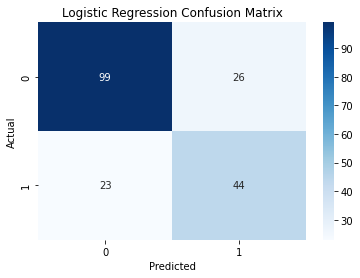

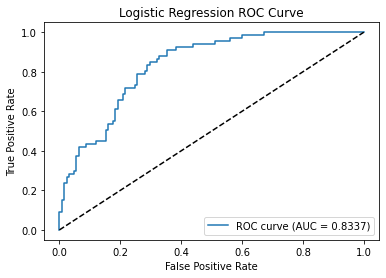


Training Random Forest...
Error with parallel processing: 'ascii' codec can't encode characters in position 18-20: ordinal not in range(128)
Falling back to single process...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

----- Random Forest best model -----
best params: {'clf__max_depth': 6, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
accuracy: 0.734375
precision: 0.6081081081081081
recall: 0.6716417910447762
f1: 0.6382978723404256
roc_auc: 0.8202985074626866
              precision    recall  f1-score   support

         0.0     0.8136    0.7680    0.7901       125
         1.0     0.6081    0.6716    0.6383        67

    accuracy                         0.7344       192
   macro avg     0.7108    0.7198    0.7142       192
weighted avg     0.7419    0.7344    0.7371       192



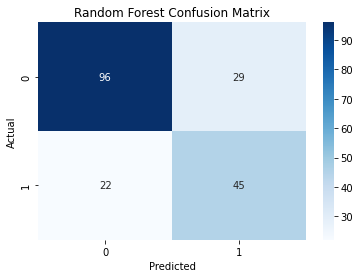

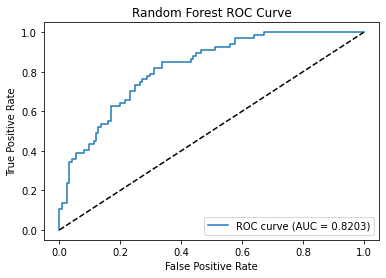


Training Gradient Boosting...
Error with parallel processing: 'ascii' codec can't encode characters in position 18-20: ordinal not in range(128)
Falling back to single process...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

----- Gradient Boosting best model -----
best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__n_estimators': 200}
accuracy: 0.7395833333333334
precision: 0.639344262295082
recall: 0.582089552238806
f1: 0.609375
roc_auc: 0.8122985074626864
              precision    recall  f1-score   support

         0.0     0.7863    0.8240    0.8047       125
         1.0     0.6393    0.5821    0.6094        67

    accuracy                         0.7396       192
   macro avg     0.7128    0.7030    0.7070       192
weighted avg     0.7350    0.7396    0.7365       192



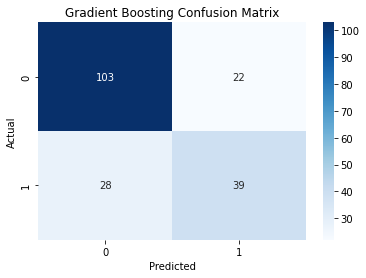

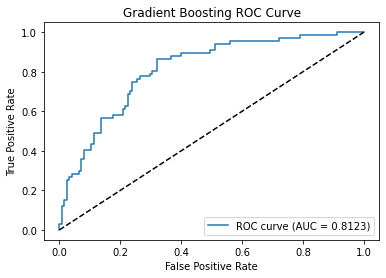


Training Hist Gradient Boosting...
Error with parallel processing: 'ascii' codec can't encode characters in position 18-20: ordinal not in range(128)
Falling back to single process...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

----- Hist Gradient Boosting best model -----
best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__max_iter': 200}
accuracy: 0.734375
precision: 0.6142857142857143
recall: 0.6417910447761194
f1: 0.6277372262773723
roc_auc: 0.7965373134328358
              precision    recall  f1-score   support

         0.0     0.8033    0.7840    0.7935       125
         1.0     0.6143    0.6418    0.6277        67

    accuracy                         0.7344       192
   macro avg     0.7088    0.7129    0.7106       192
weighted avg     0.7373    0.7344    0.7357       192



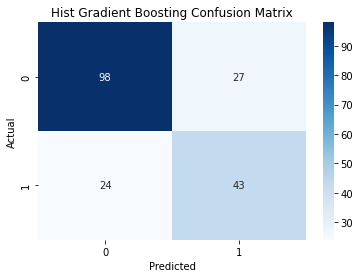

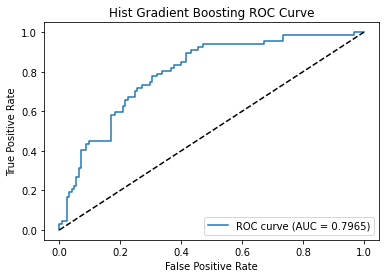


Training XGBoost...
Error with parallel processing: 'ascii' codec can't encode characters in position 18-20: ordinal not in range(128)
Falling back to single process...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


d:\Anaconda3\envs\my_env\lib\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "<ipython-input-5-39a55736e2c9>", line 61, in <module>
    grid.fit(X_train, y_train)
  File "d:\Anaconda3\envs\my_env\lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "d:\Anaconda3\envs\my_env\lib\site-packages\sklearn\model_selection\_search.py", line 952, in fit
    with parallel:
  File "d:\Anaconda3\envs\my_env\lib\site-packages\joblib\parallel.py", line 1347, in __enter__
    self._initialize_backend()
  File "d:\Anaconda3\envs\my_env\lib\site-packages\joblib\parallel.py", line 1359, in _initialize_backend
    n_jobs = self._backend.configure(n_jobs=self.n_jobs, parallel=self,
  File "d:\Anaconda3\envs\my_env\lib\site-packages\joblib\_parallel_backends.py", line 538, in c

Error: XGBoost fallback predict also failed: 'super' object has no attribute '__sklearn_tags__'

综合排序结果:
                    Model                                         BestParams  \
0     Logistic Regression                {'clf__C': 1, 'clf__penalty': 'l2'}   
1           Random Forest  {'clf__max_depth': 6, 'clf__min_samples_split'...   
3  Hist Gradient Boosting  {'clf__learning_rate': 0.1, 'clf__max_depth': ...   
2       Gradient Boosting  {'clf__learning_rate': 0.05, 'clf__max_depth':...   

   Accuracy  Precision    Recall  F1-Score   ROC AUC  
0  0.744792   0.628571  0.656716  0.642336  0.833672  
1  0.734375   0.608108  0.671642  0.638298  0.820299  
3  0.734375   0.614286  0.641791  0.627737  0.796537  
2  0.739583   0.639344  0.582090  0.609375  0.812299  

最佳模型已保存: Logistic Regression -> ../report/best_diabetes_model.pkl
示例预测( {'Pregnancies': 2, 'Glucose': 120, 'BloodPressure': 70, 'SkinThickness': 20, 'Insulin': 80, 'BMI': 28.0, 'DiabetesPedigreeFunction': 0.5, 'Age': 3

d:\Anaconda3\envs\my_env\lib\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "<ipython-input-5-39a55736e2c9>", line 61, in <module>
    grid.fit(X_train, y_train)
  File "d:\Anaconda3\envs\my_env\lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "d:\Anaconda3\envs\my_env\lib\site-packages\sklearn\model_selection\_search.py", line 952, in fit
    with parallel:
  File "d:\Anaconda3\envs\my_env\lib\site-packages\joblib\parallel.py", line 1347, in __enter__
    self._initialize_backend()
  File "d:\Anaconda3\envs\my_env\lib\site-packages\joblib\parallel.py", line 1359, in _initialize_backend
    n_jobs = self._backend.configure(n_jobs=self.n_jobs, parallel=self,
  File "d:\Anaconda3\envs\my_env\lib\site-packages\joblib\_parallel_backends.py", line 538, in c

In [5]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier


# ==================== 模型定义 ====================
pipelines = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(random_state=42, max_iter=1000, solver='liblinear'))]),
    'Random Forest': Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))]),
    'Gradient Boosting': Pipeline([('scaler', StandardScaler()), ('clf', GradientBoostingClassifier(random_state=42))]),
    'Hist Gradient Boosting': Pipeline([('scaler', StandardScaler()), ('clf', HistGradientBoostingClassifier(random_state=42))])
}

if XGBClassifier is not None:
    pipelines['XGBoost'] = Pipeline([('scaler', StandardScaler()), ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1))])

# ==================== 参数网格 ====================
param_grid = {
    'Logistic Regression': {
        'clf__C': [0.01, 0.1, 1, 10],
        'clf__penalty': ['l1', 'l2']
    },
    'Random Forest': {
        'clf__n_estimators': [100, 200, 400],
        'clf__max_depth': [None, 6, 10],
        'clf__min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'clf__n_estimators': [100, 200],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__max_depth': [3, 5]
    },
    'Hist Gradient Boosting': {
        'clf__max_iter': [100, 200],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__max_depth': [3, 5]
    }
}

if 'XGBoost' in pipelines:
    param_grid['XGBoost'] = {
        'clf__n_estimators': [100, 200],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__max_depth': [3, 5]
    }

# ==================== 模型训练 ====================
best_models = {}
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipe in pipelines.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")
    # 使用多进程加速，但避免编码问题
    try:
        grid = GridSearchCV(pipe, param_grid[name], cv=cv, 
                           scoring='f1', n_jobs=-1, verbose=1)
        grid.fit(X_train, y_train)
    except Exception as e:
        print(f"Error with parallel processing: {e}")
        print("Falling back to single process...")
        grid = GridSearchCV(pipe, param_grid[name], cv=cv, 
                           scoring='f1', n_jobs=1, verbose=1)
        grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    # 预测
    y_pred = None
    try:
        y_pred = grid.predict(X_test)
    except Exception as e:
        print(f"Warning: {name} grid.predict failed: {e}")
        try:
            y_pred = grid.best_estimator_.predict(X_test)
            print(f"Info: {name} using best_estimator_.predict fallback")
        except Exception as e2:
            print(f"Error: {name} fallback predict also failed: {e2}")
            continue

    # 概率预测
    y_proba = None
    roc = np.nan
    try:
        if hasattr(grid, 'predict_proba'):
            y_proba = grid.predict_proba(X_test)[:, 1]
            roc = roc_auc_score(y_test, y_proba)
        elif hasattr(grid.best_estimator_, 'predict_proba'):
            y_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]
            roc = roc_auc_score(y_test, y_proba)
    except Exception as e:
        y_proba = None
        roc = np.nan
        print(f"Warning: {name} cannot predict probabilities: {e}")

    # 计算指标
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({'Model': name, 'BestParams': grid.best_params_, 'Accuracy': acc,
                    'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC AUC': roc})

    print('\n-----', name, 'best model -----')
    print('best params:', grid.best_params_)
    print('accuracy:', acc)
    print('precision:', prec)
    print('recall:', rec)
    print('f1:', f1)
    print('roc_auc:', roc)
    print(classification_report(y_test, y_pred, digits=4))

    # 混淆矩阵
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ROC曲线
    if y_proba is not None:
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        plt.figure(figsize=(6,4))
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc:.4f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} ROC Curve')
        plt.legend(loc='lower right')
        plt.show()


# ==================== 结果汇总 ====================
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print('\n综合排序结果:')
print(results_df)

import joblib
# ==================== 保存最佳模型 ====================
best_name = results_df.iloc[0]['Model']
best_model = best_models[best_name]

# 确保目录存在
os.makedirs('../report', exist_ok=True)
model_path = '../report/best_diabetes_model.pkl'
joblib.dump(best_model, model_path)
print(f'\n最佳模型已保存: {best_name} -> {model_path}')

# 预测接口定义

def predict_diabetes(input_dict):
    model = joblib.load('../report/best_diabetes_model.pkl')
    sample = pd.DataFrame([input_dict])

    # 对缺失变量补0，保证列顺序一致
    for c in X_cols:
        if c not in sample.columns:
            sample[c] = 0
    sample = sample[X_cols]

    try:
        label = model.predict(sample)[0]
    except Exception as ex:
        raise ValueError(f'预测失败: {ex}')

    if hasattr(model, 'predict_proba'):
        prob = model.predict_proba(sample)[0,1]
    elif hasattr(model, 'decision_function'):
        prob = model.decision_function(sample)
        prob = (prob - prob.min()) / (prob.max() - prob.min())
    else:
        prob = np.nan

    return label, prob

sample_input = {
    'Pregnancies': 2,
    'Glucose': 120,
    'BloodPressure': 70,
    'SkinThickness': 20,
    'Insulin': 80,
    'BMI': 28.0,
    'DiabetesPedigreeFunction': 0.5,
    'Age': 32
}
pred, prob = predict_diabetes(sample_input)
print('示例预测(', sample_input, ') => label:', pred, '概率:', round(prob,4) if not np.isnan(prob) else prob)



# 高级模型可视化

本单元展示：
1. 各模型 ROC 曲线对比
2. 各模型 Precision-Recall 曲线对比
3. 树模型特征重要性（Top-10）
4. 最佳模型校准曲线（Calibration Curve + Brier score）

XGBoost 没有 predict_proba：'super' object has no attribute '__sklearn_tags__'


d:\Anaconda3\envs\my_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\my_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\my_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\my_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\my_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu San

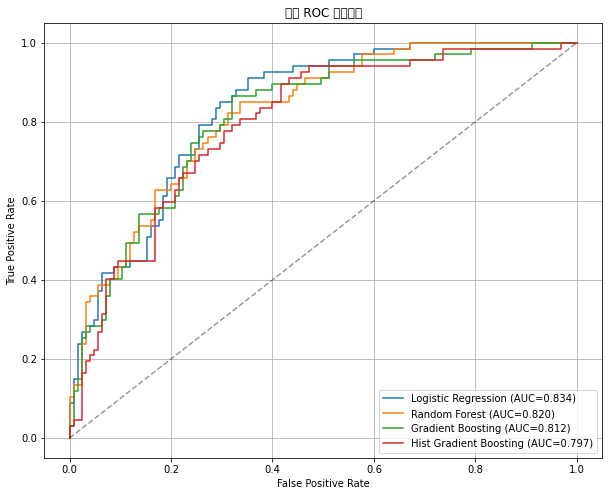

d:\Anaconda3\envs\my_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\my_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\my_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\my_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\my_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu San

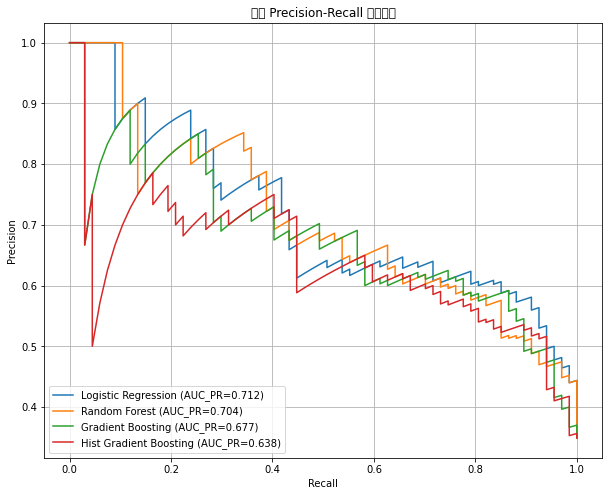

<ipython-input-6-430c182fd2a2>:53: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-430c182fd2a2>:53: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-430c182fd2a2>:53: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-430c182fd2a2>:53: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-430c182fd2a2>:53: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Anaconda3\envs\my_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\my_env\lib\site-packages\IPython\

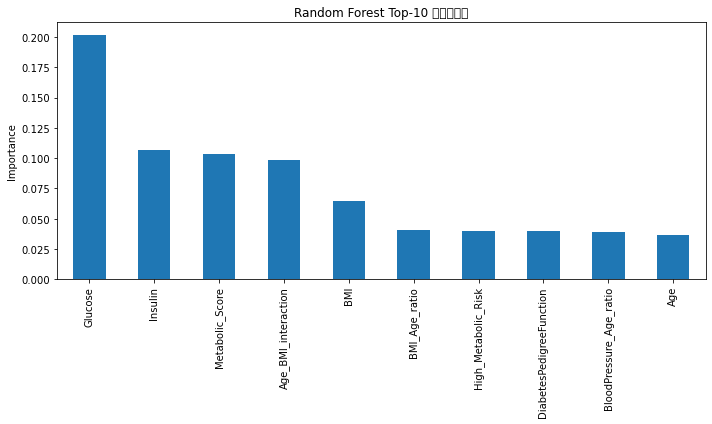

<ipython-input-6-430c182fd2a2>:53: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-430c182fd2a2>:53: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-430c182fd2a2>:53: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-430c182fd2a2>:53: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-430c182fd2a2>:53: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Anaconda3\envs\my_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\my_env\lib\site-packages\IPython\

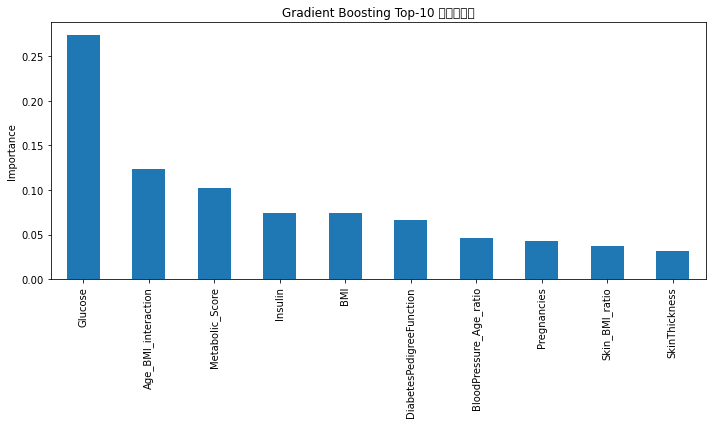

Hist Gradient Boosting 无 feature_importances_ 属性，跳过。


d:\Anaconda3\envs\my_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26657 (\N{CJK UNIFIED IDEOGRAPH-6821}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\my_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\my_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\my_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


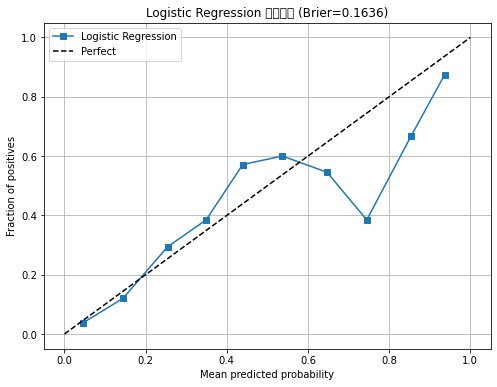

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc, brier_score_loss
from sklearn.calibration import calibration_curve

# 1. 预测概率提取（支持 predict_proba 的模型）
viz_models = []
for name, model in best_models.items():
    try:
        proba = model.predict_proba(X_test)[:, 1]
        viz_models.append((name, proba))
    except Exception as e:
        print(f"{name} 没有 predict_proba：{e}")

# 2. ROC 曲线对比
plt.figure(figsize=(10, 8))
for name, proba in viz_models:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_value = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.title("模型 ROC 曲线对比")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 3. Precision-Recall 曲线对比
plt.figure(figsize=(10, 8))
for name, proba in viz_models:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (AUC_PR={pr_auc:.3f})")
plt.title("模型 Precision-Recall 曲线对比")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

# 4. 树模型特征重要性（适用于 RandomForest/GradientBoosting/HistGradientBoosting）
tree_models = ["Random Forest", "Gradient Boosting", "Hist Gradient Boosting"]
for name in tree_models:
    if name in best_models:
        model = best_models[name]
        est = model.named_steps["clf"] if hasattr(model, "named_steps") else model
        if hasattr(est, "feature_importances_"):
            fi = pd.Series(est.feature_importances_, index=X_cols).sort_values(ascending=False)
            plt.figure(figsize=(10, 6))
            fi.head(10).plot(kind="bar", color="tab:blue")
            plt.title(f"{name} Top-10 特征重要性")
            plt.ylabel("Importance")
            plt.tight_layout()
            plt.show()
        else:
            print(f"{name} 无 feature_importances_ 属性，跳过。")

# 5. 最佳模型校准曲线
best_name = results_df.iloc[0]["Model"]
best_model = best_models[best_name]
if hasattr(best_model, "predict_proba"):
    y_prob_best = best_model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, y_prob_best, n_bins=10, strategy="uniform")
    brier = brier_score_loss(y_test, y_prob_best)

    plt.figure(figsize=(8, 6))
    plt.plot(mean_pred, frac_pos, "s-", label=f"{best_name}")
    plt.plot([0, 1], [0, 1], "k--", label="Perfect")
    plt.title(f"{best_name} 校准曲线 (Brier={brier:.4f})")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print(f"{best_name} 不支持 predict_proba，无法绘制校准曲线。")